In [1]:
import json
from COSV import VulnerabilityDatabase as VDB
import re
from datetime import datetime
import os

In [2]:
dir = "../Data/COSV"
data = VDB()
for file in os.listdir(dir):
    data.from_json(os.path.join(dir, file))

Volume of Vulnabilities Sources in 2024-10-17 to 2024-11-17
cnvd 0.4775425916365514
nvd 0.09215281362932369
ghsa 0.0678884873515746
cert 0.0
snyk 0.23180175529168817
rapid7 0.1357769747031492
cve 1.0
EDB 0.0


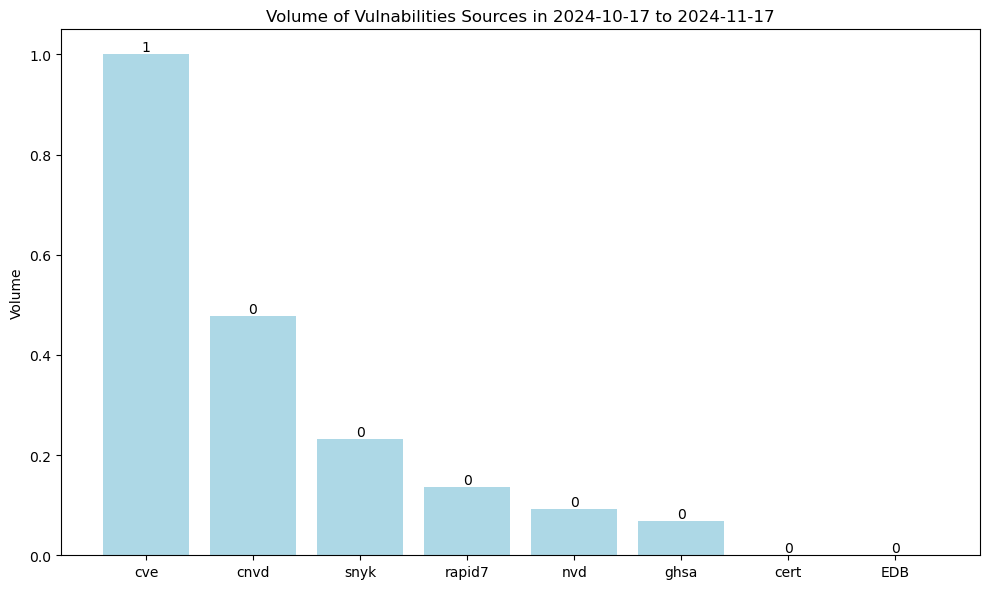

In [17]:
start_time = "2024-10-17T00:00:00Z"
end_time = "2024-11-17T00:00:00Z"
Volume_dict = data.Volume(start_time, end_time,normalize=True)
print("Volume of Vulnabilities Sources in 2024-10-17 to 2024-11-17")
for key in Volume_dict:
    print(key, Volume_dict[key])
import matplotlib.pyplot as plt
Volume_dict = dict(sorted(Volume_dict.items(), key=lambda x: x[1], reverse=True))
keys = list(Volume_dict.keys())
values = list(Volume_dict.values())

plt.figure(figsize=(10,6))
bars=plt.bar(keys, values, color='lightblue')

plt.title('Volume of Vulnabilities Sources in 2024-10-17 to 2024-11-17')

plt.ylabel('Volume')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval),ha = 'center' ,va='bottom')

plt.tight_layout()
plt.show()

In [18]:
data.build_timestand()
Time_dict = data.Timeliness(normalize=True)
print("Timeliness of Vulnabilities Sources")
for key in Time_dict:
    print(key, Time_dict[key])

Timeliness of Vulnabilities Sources
cnvd 0.015763376435391722
nvd 0.06541366943136309
ghsa 0.16875431911390562
cert 0.12041518108431079
snyk 0.24739946537617566
rapid7 0.0
EDB 1.0


In [19]:
Maintainability_dict = data.Maintainability(normalize=True)
#print(Maintainability_dict)
print("Maintainability of Vulnabilities Sources")
for key in Maintainability_dict:
    print(key, Maintainability_dict[key])

Maintainability of Vulnabilities Sources
cnvd 0.06238515929574435
nvd 0.04083251695562317
ghsa 0.0688070479909256
cert 0.0
snyk 0.025370381011556205
rapid7 0.13080268877110482
cve 1.0
EDB 0.0005576995992662205


In [20]:
Origin_dict = data.Originality(normalize=True)
print("Originality of Vulnabilities Sources")
for key in Origin_dict:
    print(key, Origin_dict[key])

Originality of Vulnabilities Sources
ghsa 0.2432611703781774
rapid7 0.0
EDB 1.0


In [22]:
Complicated_dict = data.Completeness()
print("Completeness of Vulnabilities Sources")
for key in Complicated_dict:
    print(key, Complicated_dict[key])

Completeness of Vulnabilities Sources
cnvd 0.90901
nvd 0.72727
ghsa 1.0
cert 0.63636
snyk 0.72727
rapid7 0.81818
cve 1.0
EDB 0.54545


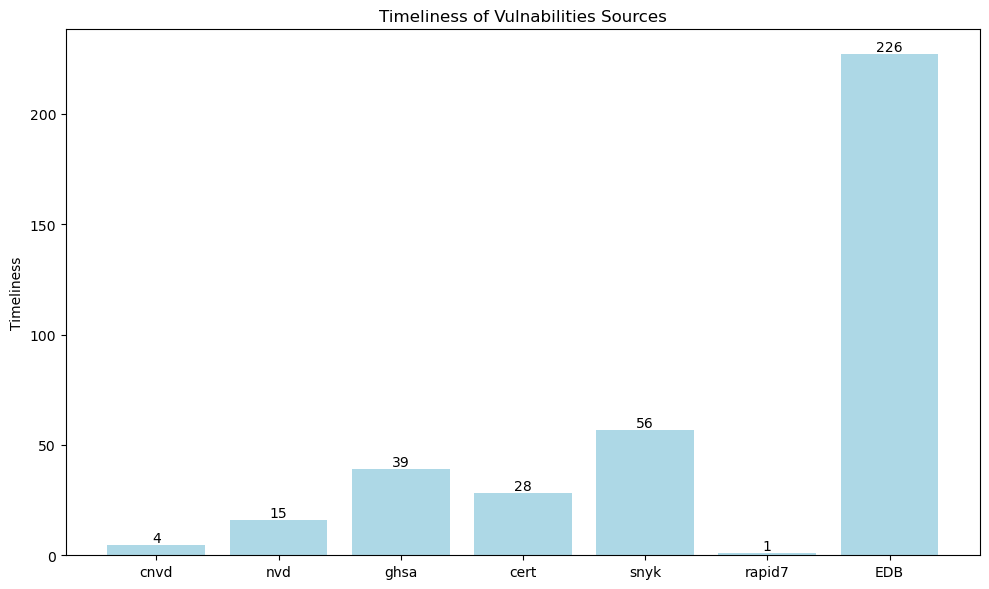

In [8]:
keys = list(Time_dict.keys())
values = list(Time_dict.values())
plt.figure(figsize=(10,6))
bars=plt.bar(keys, values, color='lightblue')

plt.title('Timeliness of Vulnabilities Sources')

plt.ylabel('Timeliness')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval),ha = 'center' ,va='bottom')

plt.tight_layout()
plt.show()

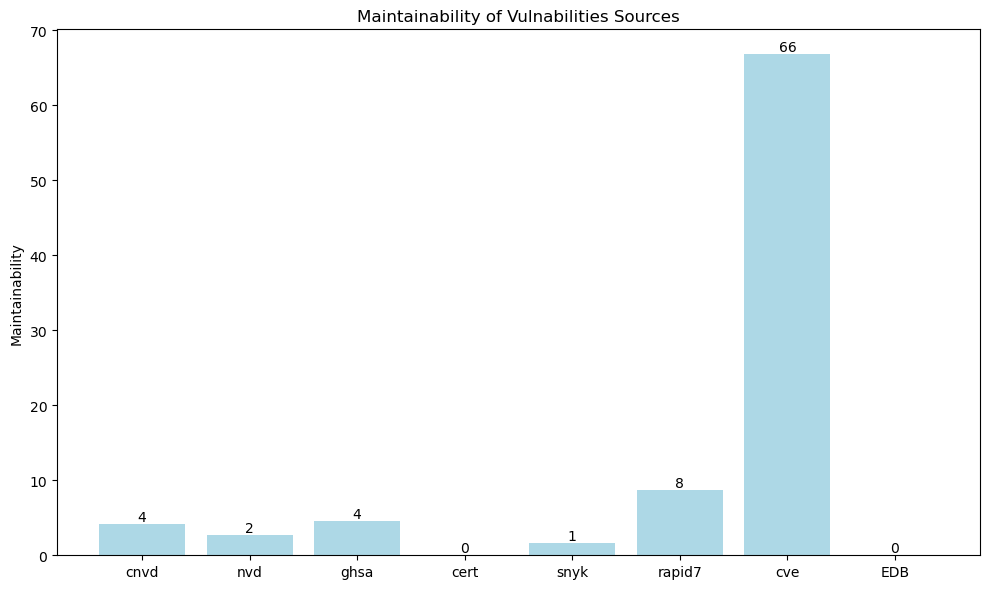

In [12]:
keys = list(Maintainability_dict.keys())
values = list(Maintainability_dict.values())
plt.figure(figsize=(10,6))
bars=plt.bar(keys, values, color='lightblue')

plt.title('Maintainability of Vulnabilities Sources')

plt.ylabel('Maintainability')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval),ha = 'center' ,va='bottom')

plt.tight_layout()
plt.show()

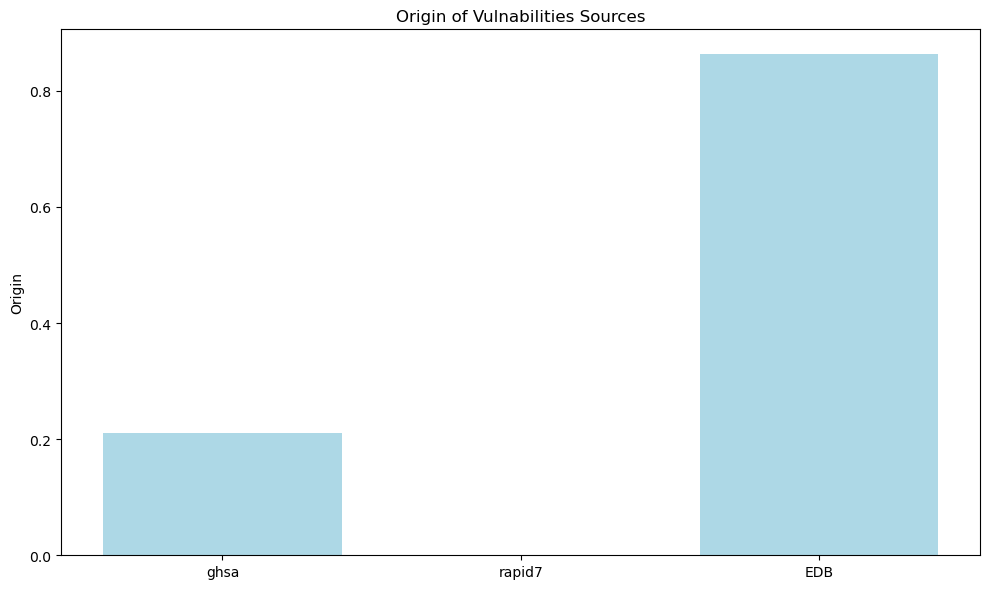

In [14]:
keys = list(Origin_dict.keys())
values = list(Origin_dict.values())
plt.figure(figsize=(10,6))
bars=plt.bar(keys, values, color='lightblue')

plt.title('Origin of Vulnabilities Sources')

plt.ylabel('Origin')

plt.tight_layout()
plt.show()

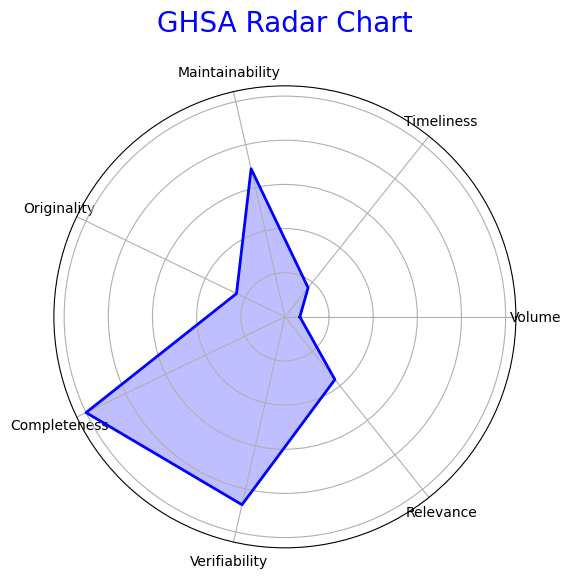

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 定义数据
labels = ['Volume', 'Timeliness', 'Maintainability', 'Originality', 'Completeness','Verifiability','Relevance']
values = [0.0678884873515746, 0.16875431911390562, 0.688070479909256, 0.2432611703781774, 1.0, 0.8732442,0.3634]

# 计算角度
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# 使雷达图闭合
values += values[:1]
angles += angles[:1]

# 创建雷达图
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=2)

# 添加标签
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

# 添加标题
plt.title('GHSA Radar Chart', size=20, color='blue', y=1.1)

# 显示图表
plt.show()

In [29]:
len(data)

121617